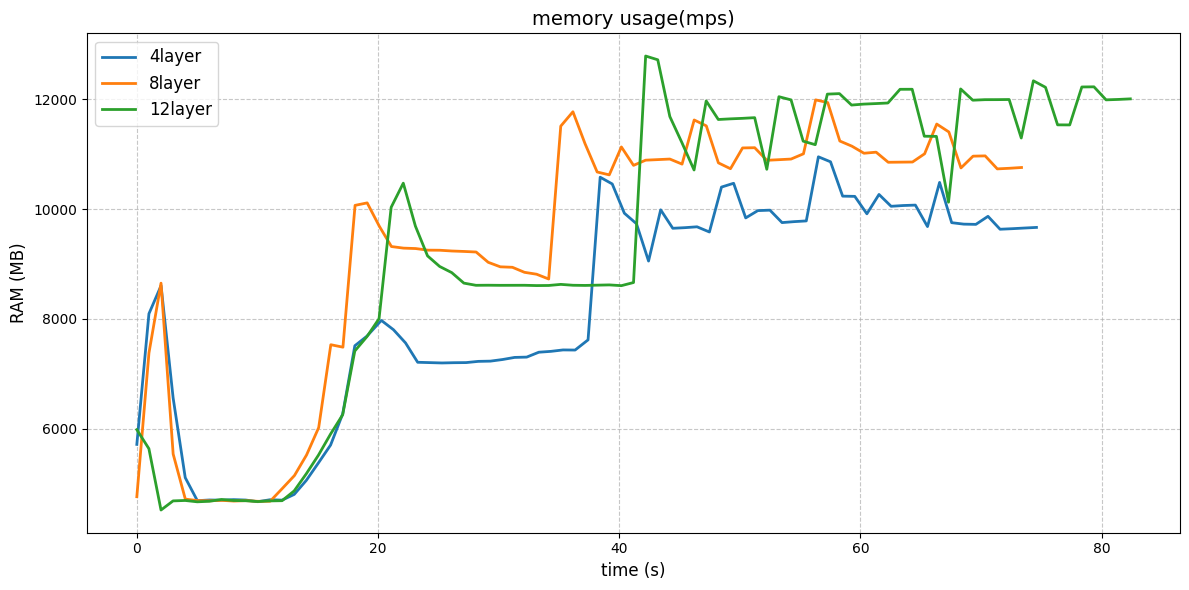

average 45-65s:
4layer: 10077.52 MB
8layer: 11120.66 MB
12layer: 11694.13 MB
4-8: 1043.14 MB
8-12: 573.47 MB
4-12: 1616.61 MB


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os


# 定义要处理的层数
layers = [4, 8, 12]

# 创建一个大的图形
plt.figure(figsize=(12, 6))
avg_values = {}

# 遍历每个层数
for layer in layers:
    # 构建文件名
    filename = f"resource_log_mps_{layer}.csv"
    
    # 检查文件是否存在
    if not os.path.exists(filename):
        print(f"文件 {filename} 不存在，跳过")
        continue
    
    # 读取CSV文件
    df = pd.read_csv(filename)
    
    # 计算相对于第一个时间戳的时间差（秒）
    df['relative_time'] = (df['timestamp'] - df['timestamp'].iloc[0])  # 假设时间戳是毫秒
    
    mask = (df['relative_time'] >= 45) & (df['relative_time'] <= 65)
    df_interval = df[mask]
    
    # 计算该区间的平均值
    avg = df_interval['memory_usage_mb'].mean()
    avg_values[layer] = avg
    
    # 绘制内存使用折线图
    plt.plot(df['relative_time'], df['memory_usage_mb'], 
             label=f'{layer}layer', 
             linewidth=2)

# 添加图表元素
plt.title('memory usage(mps)', fontsize=14)
plt.xlabel('time (s)', fontsize=12)
plt.ylabel('RAM (MB)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()

# 显示图形
plt.show()

print("average 45-65s:")
for layer, avg in avg_values.items():
    print(f"{layer}layer: {avg:.2f} MB")

print(f"4-8: {(avg_values[8]-avg_values[4]):.2f} MB")
print(f"8-12: {(avg_values[12]-avg_values[8]):.2f} MB")
print(f"4-12: {(avg_values[12]-avg_values[4]):.2f} MB")